In [1]:
import matplotlib.pyplot as plt
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
import file_utils
from file_utils import readData, float2latex
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/lane/Aug_Sept2025"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Aug2025/"

colors = ["darkorange", "crimson", "#2544D0", "olive", "orangered", "#2544D0", "k"]

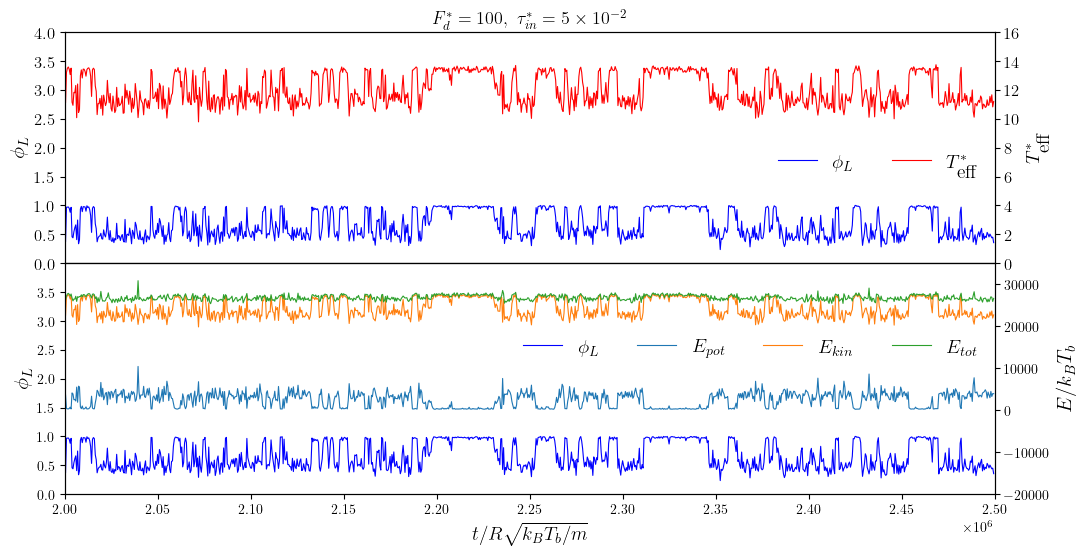

In [2]:
# Plot time series of lane order parameter, effective temperature, kinetic, potential, and total energies

eq_steps = 1e7
dt = 5e-4
Nevery = 10

lw = 0.8
ms = 3
fig, ax = plt.subplots(2, 1, figsize = (12, 6))

# Extract energy and temperature data from thermo.dat
fpath = os.path.join(dirpath, "Fd100", "tau_5e-2", "thermo.dat")
[data, _] = readData(fpath, 1)

step = data[0][1::Nevery]
T = data[1][1::Nevery]
epot = data[2][1::Nevery]
ekin = data[3][1::Nevery]
etot = data[4][1::Nevery]

time = [(i - eq_steps)*dt for i in step]

# Extract order parameter data from laneOrder_all.dat
fpath = os.path.join(dirpath, "Fd100", "tau_5e-2", "laneOrder_all.dat")
[data, _] = readData(fpath, 1)

phi = data[1][1::Nevery]

# Plot order parameetr vs temperature
ax0_t = ax[0].twinx()

lines_A = []
line1, = ax[0].plot(time, phi, "b-", lw = lw, label = r"$\phi_L$")
line2, = ax0_t.plot(time, T, "r-", lw = lw, label = r"$T^*_{\textrm{eff}}$")
lines_A.append(line1)
lines_A.append(line2)

# Plot order parameter vs energies
ax1_t = ax[1].twinx()

lines_B = []
line1, = ax[1].plot(time, phi, "b-", lw = lw, label = r"$\phi_L$")
line2, = ax1_t.plot(time, epot, "-", lw = lw, label = r"$E_{pot}$")
line3, = ax1_t.plot(time, ekin, "-", lw = lw, label = r"$E_{kin}$")
line4, = ax1_t.plot(time, etot, "-", lw = lw, label = r"$E_{tot}$")
lines_B.append(line1)
lines_B.append(line2)
lines_B.append(line3)
lines_B.append(line4)

ax[0].set_xlim(2e6, 2.5e6)
ax[0].set_ylim(0, 4)
ax0_t.set_ylim(0, 16)
ax[0].set_xticks([])
ax[0].set_yticks(np.arange(0, 4.5, 0.5))
ax0_t.set_yticks(np.arange(0, 18, 2))
ax[0].set_ylabel(r"$\phi_L$", fontsize = 15)
ax0_t.set_ylabel(r"$T^*_{\textrm{eff}}$", fontsize = 14)
ax[0].tick_params(axis = "y", which = "major", labelsize = 12)
ax0_t.tick_params(axis = "y", which = "major", labelsize = 12)
ax[0].legend(handles = lines_A, ncols = 2, fontsize = 14, frameon = False, bbox_to_anchor = (1, 0.55))
ax[0].set_title(r"$F_d^* = 100, ~\tau_{in}^* = 5\times 10^{-2}$", fontsize = 13)

ax[1].set(xlim = (2e6, 2.5e6), ylim = (0, 4))
ax1_t.set(ylim = (-20e3, 35e3))
ax[1].set_xticks(np.arange(2e6, 2.525e6, 5e4))
ax[1].set_yticks(np.arange(0, 4.0, 0.5))
ax1_t.set_yticks(np.arange(-20e3, 35e3, 10e3))
ax[1].set_xlabel(r"$t/R\sqrt{k_BT_b/m}$", fontsize = 14)
ax[1].set_ylabel(r"$\phi_L$", fontsize = 15)
ax1_t.set_ylabel(r"$E/k_BT_b$", fontsize = 15)
ax[1].legend(handles = lines_B, ncols = 4, fontsize = 14, frameon = False, bbox_to_anchor = (1, 0.75))

plt.subplots_adjust(hspace = 0)

# fig.savefig(os.path.join(figpath, "time_order_energy_Fd100.png"), dpi = 500, bbox_inches = "tight")

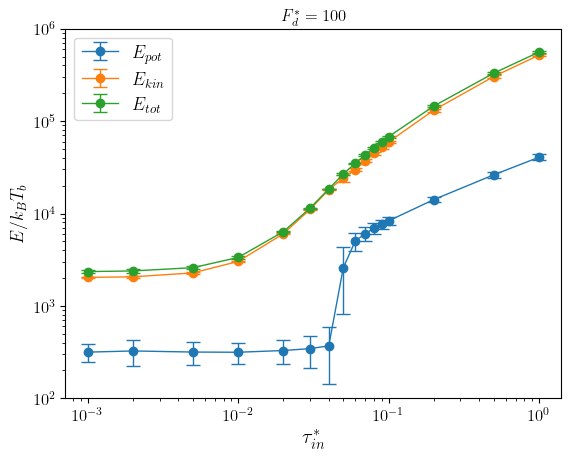

In [18]:
# Plot average energies vs inertial time for a given Fd

tau_list = ["1e-3", "2e-3", "5e-3", "1e-2", "2e-2", "3e-2", "4e-2", "5e-2", "6e-2", "7e-2", "8e-2", "9e-2", "10e-2", "2e-1", "5e-1", "1e0"]

frameStart = int(3e4) 

lw = 1
ms = 6
fig, ax = plt.subplots()

epot_avg = []
ekin_avg = []
etot_avg = []

epot_std = []
ekin_std = []
etot_std = []

for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "Fd100", "tau_{tau}".format(tau = tau_list[i]), "thermo.dat")

    [data, _] = readData(fpath, 1)

    epot = data[2][frameStart::]
    avg = sum(epot)/len(epot)
    std = [(i - avg)**2 for i in epot]
    std = m.sqrt(sum(std)/(len(epot) - 1))
    epot_avg.append(avg)
    epot_std.append(std)
    
    ekin = data[3][frameStart::]
    avg = sum(ekin)/len(ekin)
    std = [(i - avg)**2 for i in ekin]
    std = m.sqrt(sum(std)/(len(ekin) - 1))
    ekin_avg.append(avg)
    ekin_std.append(std)

    etot = data[4][frameStart::]
    avg = sum(etot)/len(etot)
    std = [(i - avg)**2 for i in etot]
    std = m.sqrt(sum(std)/(len(etot) - 1))
    etot_avg.append(avg)
    etot_std.append(std)

tau = [liteval(i) for i in tau_list]

ax.errorbar(tau, epot_avg, xerr = None, yerr = epot_std, marker = "o", ls = "-", ms = ms, lw = lw, 
            elinewidth = 1, capsize = 5, label = r"$E_{pot}$")
ax.errorbar(tau, ekin_avg, xerr = None, yerr = ekin_std, marker = "o", ls = "-", ms = ms, lw = lw,
            elinewidth = 1, capsize = 5, label = r"$E_{kin}$")
ax.errorbar(tau, etot_avg, xerr = None, yerr = etot_std, marker = "o", ls = "-", ms = ms, lw = lw,
            elinewidth = 1, capsize = 5, label = r"$E_{tot}$")

ax.set(ylim = (1e2, 1e6))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\tau_{in}^*$", fontsize = 15)
ax.set_ylabel(r"$E/k_BT_b$", fontsize = 13)
ax.tick_params(axis = "both", which = "major", labelsize = 12)
ax.set_title(r"$F_d^* = 100$", fontsize = 12)
ax.legend(fontsize = 13)

# fig.savefig(os.path.join(figpath, "Fd100_energy.png"), dpi = 600, bbox_inches = "tight")